In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df=pd.read_csv(r"Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [4]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
df.dtypes

area_type           str
availability        str
location            str
size                str
society             str
total_sqft          str
bath            float64
balcony         float64
price           float64
dtype: object

In [ ]:
# EDA

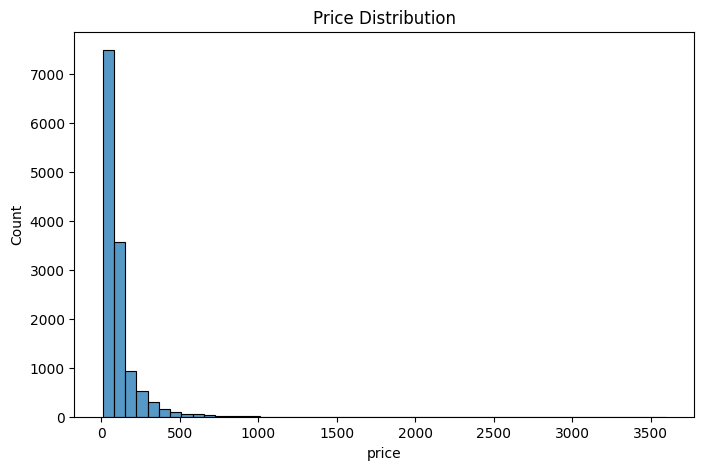

In [6]:
# Price Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50)
plt.title("Price Distribution")
plt.show()

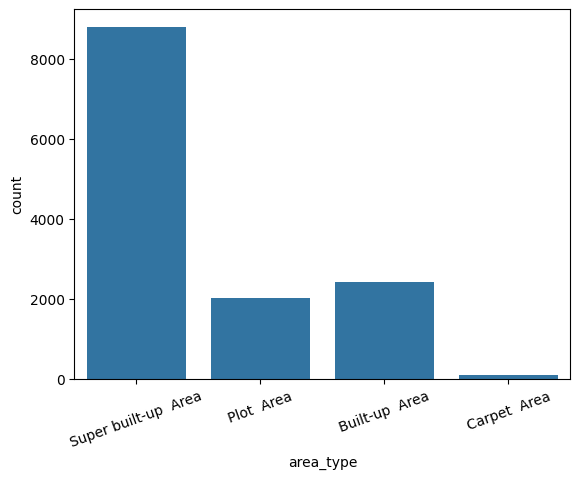

In [7]:
# Area Type Count

sns.countplot(x="area_type", data=df)
plt.xticks(rotation=20)
plt.show()

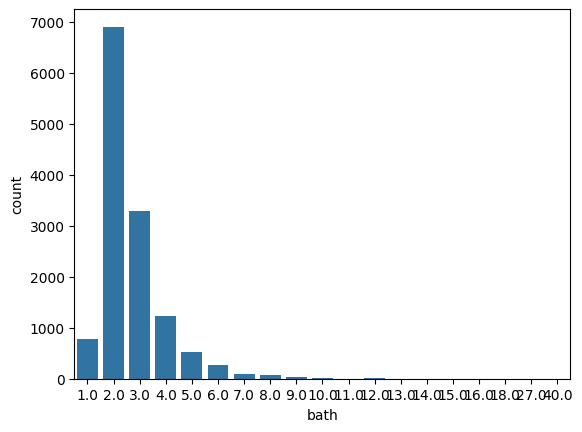

In [8]:
# Bathroom Distribution

sns.countplot(x="bath", data=df)
plt.show()

In [6]:
df["balcony"]=df["balcony"].fillna(df["balcony"].mode()[0])


In [7]:
df["bath"]=df["bath"].fillna(df["bath"].mode()[0])
df["size"]=df["size"].fillna(df["size"].mode()[0])

In [14]:
df.dropna(subset=["location"],inplace=True)


In [15]:
df.drop(columns="society" ,inplace=True)

In [16]:
df.drop(columns="availability" ,inplace=True)

In [17]:
def extract_bhk(size):
    try:
        if " " in str(size):
            a,b = size.split(" ")
            return float(a)
    except:
        return None

In [18]:
df["size"]=df["size"].apply(extract_bhk)


In [19]:
df.head()

,area_type,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2.0,1056.0,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4.0,2600.0,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3.0,1440.0,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3.0,1521.0,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2.0,1200.0,2.0,1.0,51.00


In [20]:
print(df["total_sqft"].unique())

[1056.  2600.  1440.  ... 1258.5  774.  4689. ]


In [9]:
def convert_sqft(x):
    try:
        if "-" in str (x):
            a,b = x.split("-")
            return (float(a) + float(b))/ 2
        return float(x)
    except:
        return None


In [12]:
df["total_sqft"] = df["total_sqft"].apply(convert_sqft)

In [21]:
df["total_sqft"]=df["total_sqft"].fillna(df["total_sqft"].mean(),inplace=True)

C:\Users\Rahul\AppData\Local\Temp\ipykernel_11336\2425656479.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["total_sqft"]=df["total_sqft"].fillna(df["total_sqft"].mean(),inplace=True)


In [22]:
from sklearn.preprocessing import LabelEncoder

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [53]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [25]:
from sklearn.preprocessing import LabelEncoder

labelen = {}

for col in ["area_type", "location"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    labelen[col] = le

In [26]:
# save the dictionary of encoders

import pickle 
with open("labelen.pkl","wb") as f:
    pickle.dump(labelen,f)

In [27]:
X = df.drop('price', axis=1)
y = df['price']

In [34]:
# import train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=30)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# Define models
models = {
    #"Logistic Regression": LogisticRegression(),
    # "Support Vector Classifier": SVC(),
    "linear regression" : LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(),
    # "K Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    # "Gaussian Naive Bayes": GaussianNB(),
    # "AdaBoost Classifier": AdaBoostClassifier(),
    # "Gradient Boosting Classifier": GradientBoostingClassifier(),
    
}

# Train and evaluate each model
for name, model in models.items():
    print("="*50)
    print("Model:", name)
    # Train the model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Calculate metrics
    # accuracy = accuracy_score(y_test, y_pred)
    # classification_rep = classification_report(y_test, y_pred)
    # conf_matrix = confusion_matrix(y_test, y_pred)
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

    print(model.score(X_train, y_train))
    print(model.score(X_test, y_test))

    # # Print metrics
 #print("Accuracy:", accuracy)
 # print("Classification Report:\n", classification_rep)
 # print("Confusion Matrix:\n", conf_matrix)

Model: linear regression
MAE: 44.32929780961735
RMSE: 88.98633362652214
R2: 0.48778207218466796
0.37742073862270475
0.48778207218466796
Model: Random Forest Regressor
MAE: 31.6036331429591
RMSE: 82.77266045573799
R2: 0.5568181392665635
0.9381347434123717
0.5568181392665635
Model: Decision Tree Regressor
MAE: 39.87202509492001
RMSE: 108.72210066899567
R2: 0.2353832320756416
0.9986320204940181
0.2353832320756416


In [ ]:
# selecting one best model

In [49]:
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
import numpy as np
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
y_pred = model.predict(X_test)


print("MAE :" , mean_absolute_error(y_test,y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 SCORE: ",r2_score(y_test,y_pred))
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

MAE : 31.729606933999552
RMSE:  81.280367621793
R2 SCORE:  0.5726541742412693
0.9370715521080355
0.5726541742412693


In [52]:
# Save model
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)